In [5]:
pip install --upgrade statsmodels scipy

Note: you may need to restart the kernel to use updated packages.


In [6]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [7]:
df = yf.download('GC=F', start='2010-01-01')['Close']

[*********************100%***********************]  1 of 1 completed


In [8]:
print(type(df))
print(df.dtypes)

<class 'pandas.DataFrame'>
Ticker
GC=F    float64
dtype: object


In [9]:
# To covert dataframe into series
df = df.squeeze()

In [10]:
print(type(df))
print(df.dtypes)

<class 'pandas.Series'>
float64


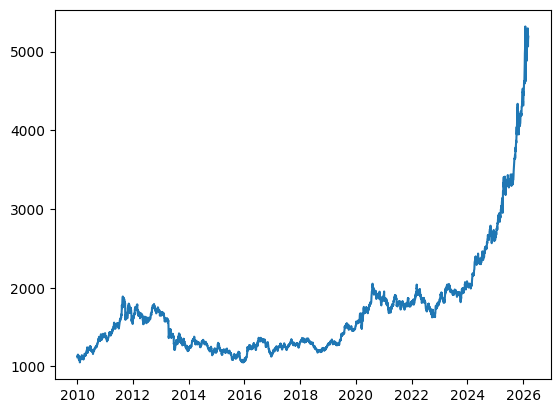

In [11]:
plt.plot(df)
plt.show()

In [12]:
# Train Test Split

to_row = int(len(df)*0.9)

training_data = list(df[:to_row])
testing_data = list(df[to_row:])

In [13]:
training_data

[1117.699951171875,
 1118.0999755859375,
 1135.9000244140625,
 1133.0999755859375,
 1138.199951171875,
 1150.699951171875,
 1128.9000244140625,
 1136.4000244140625,
 1142.5999755859375,
 1130.0999755859375,
 1139.699951171875,
 1112.300048828125,
 1102.699951171875,
 1089.199951171875,
 1095.199951171875,
 1097.9000244140625,
 1084.4000244140625,
 1083.5999755859375,
 1083.0,
 1104.300048828125,
 1117.4000244140625,
 1111.4000244140625,
 1062.4000244140625,
 1052.199951171875,
 1065.699951171875,
 1076.699951171875,
 1075.800048828125,
 1094.199951171875,
 1089.5,
 1119.300048828125,
 1119.5,
 1118.0,
 1121.300048828125,
 1112.5999755859375,
 1102.699951171875,
 1096.5,
 1107.800048828125,
 1118.300048828125,
 1117.800048828125,
 1136.9000244140625,
 1142.699951171875,
 1132.5999755859375,
 1134.800048828125,
 1123.5999755859375,
 1122.0,
 1107.800048828125,
 1108.0,
 1101.5,
 1105.0999755859375,
 1122.199951171875,
 1124.0,
 1127.4000244140625,
 1107.4000244140625,
 1099.300048828125,

In [14]:
testing_data

[2380.0,
 2377.300048828125,
 2405.0,
 2426.5,
 2435.0,
 2425.699951171875,
 2401.699951171875,
 2389.10009765625,
 2390.5,
 2422.199951171875,
 2432.10009765625,
 2462.39990234375,
 2466.699951171875,
 2439.39990234375,
 2453.10009765625,
 2498.60009765625,
 2501.800048828125,
 2511.300048828125,
 2508.39990234375,
 2478.89990234375,
 2508.39990234375,
 2517.699951171875,
 2516.0,
 2501.0,
 2525.699951171875,
 2493.800048828125,
 2489.89990234375,
 2493.39990234375,
 2511.39990234375,
 2493.5,
 2501.800048828125,
 2512.300048828125,
 2512.10009765625,
 2551.199951171875,
 2581.300048828125,
 2580.39990234375,
 2564.300048828125,
 2570.699951171875,
 2588.0,
 2619.89990234375,
 2626.5,
 2651.199951171875,
 2659.199951171875,
 2669.89990234375,
 2644.300048828125,
 2636.10009765625,
 2667.300048828125,
 2647.10009765625,
 2657.10009765625,
 2645.800048828125,
 2644.800048828125,
 2615.0,
 2606.0,
 2620.60009765625,
 2657.60009765625,
 2647.800048828125,
 2661.39990234375,
 2674.0,
 2691

In [15]:
model_predictions = []
n_test_observation = len(testing_data)

for i in range(n_test_observation):

    model = ARIMA(training_data, order=(4,1,0))
    model_fit = model.fit()

    output = model_fit.forecast()

    yhat = output[0]

    model_predictions.append(yhat)

    actual_test_value = testing_data[i]

    training_data.append(actual_test_value)

In [30]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 4067
Model:                 ARIMA(4, 1, 0)   Log Likelihood              -18649.878
Date:                Tue, 10 Mar 2026   AIC                          37309.755
Time:                        08:22:07   BIC                          37341.307
Sample:                             0   HQIC                         37320.930
                               - 4067                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0483      0.006     -8.595      0.000      -0.059      -0.037
ar.L2         -0.0929      0.004    -24.082      0.000      -0.100      -0.085
ar.L3         -0.0034      0.008     -0.447      0.6

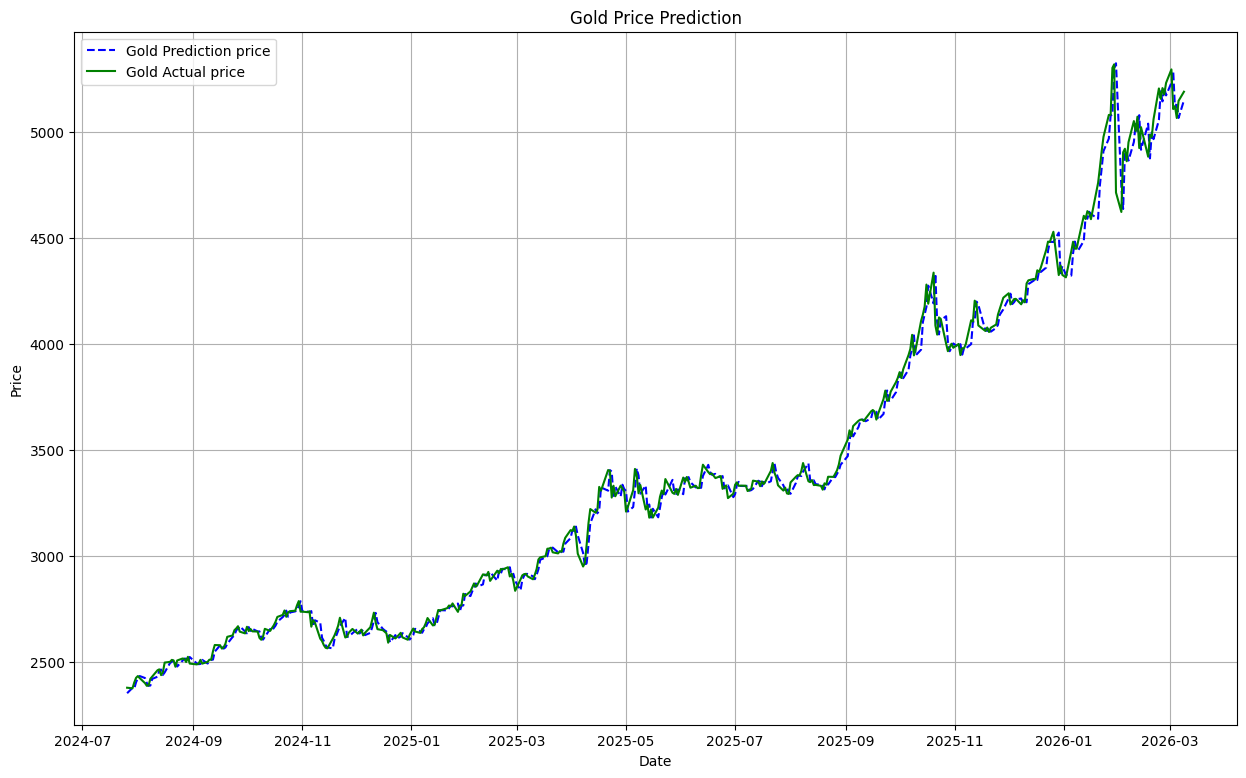

In [38]:
plt.figure(figsize=(15,9))
plt.grid(True)

date_range = df[to_row:].index

plt.plot(date_range, model_predictions, color = 'blue', linestyle = 'dashed', label = 'Gold Prediction price')
plt.plot(date_range, testing_data, color = 'green', label = 'Gold Actual price')

plt.title('Gold Price Prediction')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

In [36]:
# Mean Absolute Percentage Error
mape = np.mean(np.abs(np.array(model_predictions) - np.array(testing_data)) / np.abs(testing_data))
print('MAPE: ' +str(mape))

# Around 1% MAPE implies the model is about 99% accurate in predicting the test set observation.

MAPE: 0.010004618197345293
